# Healthcare Pharmacy E-Commerce Chatbot Training

This notebook trains the baseline chatbot models for the Healthcare Pharmacy E-Commerce Microservices System. The data is self-seeded for an academic demo and is not clinically validated.

The notebook exports artifacts for `services/chatbot_service/artifacts/`:

- `intent_model.pkl`
- `intent_vectorizer.pkl`
- `category_model.pkl`
- `category_vectorizer.pkl`
- `label_encoders.pkl`
- `model_metadata.json`
- `metrics.json`

## 1. Project Introduction

The chatbot supports safe pharmacy e-commerce product consultation. It predicts a user intent and, when relevant, recommends one of the product catalog categories. It must not diagnose disease, claim cures, or replace advice from a doctor or pharmacist.

Baseline approach:

- TF-IDF text vectorization
- Logistic Regression intent classifier
- Logistic Regression category classifier

## 2. Dataset Loading

Upload `chatbot_training_seed.csv` to a Kaggle dataset. This notebook searches common Kaggle and local repository paths.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import re

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
TEST_SIZE = 0.20

def find_dataset() -> Path:
    candidates = [
        Path('ml/datasets/chatbot_training_seed.csv'),
        Path('../datasets/chatbot_training_seed.csv'),
        Path('/kaggle/input/chatbot-training-seed/chatbot_training_seed.csv'),
        Path('/kaggle/input/healthcare-pharmacy-chatbot/chatbot_training_seed.csv'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        matches = list(kaggle_input.rglob('chatbot_training_seed.csv'))
        if matches:
            return matches[0]
    raise FileNotFoundError('Could not find chatbot_training_seed.csv. Upload it as a Kaggle dataset or run from the repository root.')

DATASET_PATH = find_dataset()
OUTPUT_ROOT = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
ARTIFACT_DIR = OUTPUT_ROOT / 'ml' / 'artifacts'
REPORT_DIR = OUTPUT_ROOT / 'ml' / 'reports'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Dataset: {DATASET_PATH}')
print(f'Artifacts: {ARTIFACT_DIR}')

Dataset: ml\datasets\chatbot_training_seed.csv
Artifacts: C:\Users\nguye\Desktop\Healthcare_Pharmacy_E-Commerce\ml\artifacts


In [2]:
df = pd.read_csv(DATASET_PATH)
required_columns = {
    'text',
    'intent',
    'target_category',
    'safe_response_template',
    'requires_medical_disclaimer',
}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

df['text'] = df['text'].astype(str)
df['intent'] = df['intent'].astype(str)
df['target_category'] = df['target_category'].fillna('').astype(str).str.strip()
df.head()

,text,intent,target_category,safe_response_template,requires_medical_disclaimer
0,Do you have Comfort Relief Tablets?,product_search,OTC Medicine,You can browse matching product results in the...,True
1,Show me products like MediWell Everyday Cold C...,product_search,OTC Medicine,You can browse matching product results in the...,True
2,Do you have Gentle Throat Lozenges?,product_search,OTC Medicine,You can browse matching product results in the...,True
3,Show me products like HealthNest Cooling Vapor...,product_search,OTC Medicine,You can browse matching product results in the...,True
4,Do you have Saline Nasal Spray?,product_search,OTC Medicine,You can browse matching product results in the...,True


## 3. Dataset Inspection

In [3]:
print('Rows:', len(df))
print('Columns:', list(df.columns))
print('\nMissing values:')
display(df.isna().sum())
display(df.sample(min(10, len(df)), random_state=RANDOM_STATE))

Rows: 1110
Columns: ['text', 'intent', 'target_category', 'safe_response_template', 'requires_medical_disclaimer']

Missing values:


text                           0
intent                         0
target_category                0
safe_response_template         0
requires_medical_disclaimer    0
dtype: int64

,text,intent,target_category,safe_response_template,requires_medical_disclaimer
884,Do you charge real money in this demo without ...,payment_question,,This academic demo uses simulated payments onl...,False
342,What skincare category helps with dry skin care,skincare_support,Skincare,You may want to browse Skincare products such ...,True
56,Do you have Weekly Pill Organizer?,product_search,Medical Devices,You can browse matching product results in the...,True
694,Can staff see my order for fulfillment without...,order_status_question,,You can check order progress from the customer...,False
721,Can you show my order history please,order_status_question,,You can check order progress from the customer...,False
614,Can you recommend a product category for sugge...,first_aid_support,First Aid,You may want to browse First Aid products such...,True
1003,what should I type here for the academic demo,fallback,,"I can help with product categories, catalog se...",False
88,Do you have Denture Cleaning Tablets?,product_search,Oral Care,You can browse matching product results in the...,True
409,Suggest skin comfort products,skincare_support,Skincare,You may want to browse Skincare products such ...,True
801,What does pending shipment mean please,shipping_question,,You can review shipment status from your order...,False


## 4. Label Distribution

,count
intent,
product_search,100
category_recommendation,100
digestive_support,70
vitamin_advice,70
skincare_support,70
oral_care_support,70
baby_care_support,70
first_aid_support,70
medical_device_question,70


,count
target_category,
Digestive Health,90
Vitamins & Minerals,90
Mother & Baby,90
Medical Devices,90
First Aid,90
Skincare,90
Oral Care,90
OTC Medicine,20
Personal Care,20


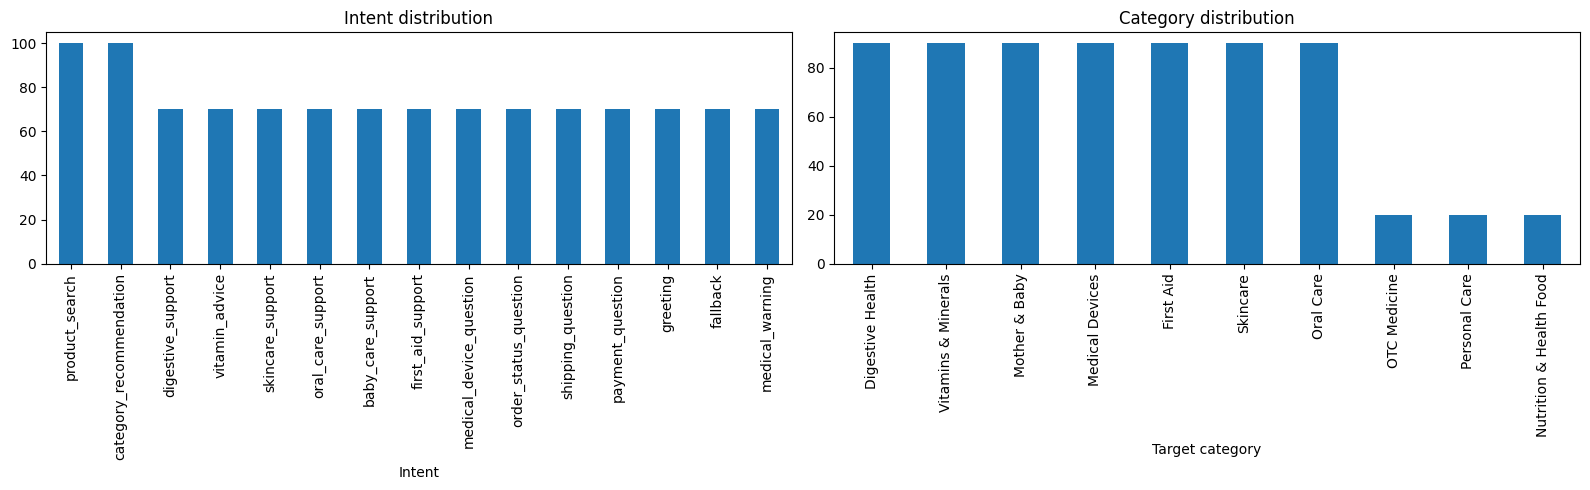

In [4]:
intent_counts = df['intent'].value_counts().sort_values(ascending=False)
category_counts = df[df['target_category'] != '']['target_category'].value_counts().sort_values(ascending=False)

display(intent_counts.to_frame('count'))
display(category_counts.to_frame('count'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
intent_counts.plot(kind='bar', ax=axes[0], title='Intent distribution')
category_counts.plot(kind='bar', ax=axes[1], title='Category distribution')
axes[0].set_xlabel('Intent')
axes[1].set_xlabel('Target category')
plt.tight_layout()
plt.show()

## 5. Train/Test Split

In [5]:
category_df = df[df['target_category'] != ''].copy()

print('Intent training rows:', len(df))
print('Category training rows:', len(category_df))
print('Intent labels:', sorted(df['intent'].unique()))
print('Category labels:', sorted(category_df['target_category'].unique()))

Intent training rows: 1110
Category training rows: 690
Intent labels: ['baby_care_support', 'category_recommendation', 'digestive_support', 'fallback', 'first_aid_support', 'greeting', 'medical_device_question', 'medical_warning', 'oral_care_support', 'order_status_question', 'payment_question', 'product_search', 'shipping_question', 'skincare_support', 'vitamin_advice']
Category labels: ['Digestive Health', 'First Aid', 'Medical Devices', 'Mother & Baby', 'Nutrition & Health Food', 'OTC Medicine', 'Oral Care', 'Personal Care', 'Skincare', 'Vitamins & Minerals']


## 6. Text Preprocessing

The preprocessing stays intentionally simple: lowercase, remove non-alphanumeric punctuation, and normalize whitespace. The TF-IDF vectorizer uses unigrams and bigrams so short product and symptom phrases remain useful.

In [6]:
def clean_text(value):
    text = '' if value is None else str(value)
    text = text.lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def summarize_split(labels):
    return {str(label): int(count) for label, count in pd.Series(labels).value_counts().sort_index().items()}

def train_baseline(texts, labels):
    encoder = LabelEncoder()
    y = encoder.fit_transform(labels)
    stratify = y if pd.Series(labels).value_counts().min() >= 2 else None
    x_train, x_test, y_train, y_test = train_test_split(
        texts,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify,
    )
    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=1,
        max_features=5000,
    )
    x_train_vec = vectorizer.fit_transform(x_train)
    x_test_vec = vectorizer.transform(x_test)
    model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    model.fit(x_train_vec, y_train)
    return {
        'model': model,
        'vectorizer': vectorizer,
        'encoder': encoder,
        'x_train': x_train,
        'x_test': x_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': model.predict(x_test_vec),
    }

## 7. Intent Model Training

In [7]:
intent_result = train_baseline(df['text'], df['intent'])
print('Intent model trained.')
print('Train rows:', len(intent_result['x_train']))
print('Test rows:', len(intent_result['x_test']))

Intent model trained.
Train rows: 888
Test rows: 222


## 8. Category Model Training

In [8]:
category_result = train_baseline(category_df['text'], category_df['target_category'])
print('Category model trained.')
print('Train rows:', len(category_result['x_train']))
print('Test rows:', len(category_result['x_test']))

Category model trained.
Train rows: 552
Test rows: 138


## 9. Evaluation

In [9]:
def evaluate_result(result, model_name):
    labels = list(range(len(result['encoder'].classes_)))
    target_names = [str(label) for label in result['encoder'].classes_]
    precision, recall, f1, _ = precision_recall_fscore_support(
        result['y_test'],
        result['y_pred'],
        labels=labels,
        average='weighted',
        zero_division=0,
    )
    metrics = {
        'accuracy': float(accuracy_score(result['y_test'], result['y_pred'])),
        'precision': float(precision),
        'recall': float(recall),
        'f1-score': float(f1),
        'classification_report': classification_report(
            result['y_test'],
            result['y_pred'],
            labels=labels,
            target_names=target_names,
            output_dict=True,
            zero_division=0,
        ),
        'confusion_matrix': confusion_matrix(result['y_test'], result['y_pred'], labels=labels).tolist(),
        'labels': target_names,
        'train_rows': int(len(result['x_train'])),
        'test_rows': int(len(result['x_test'])),
        'train_label_distribution': summarize_split(result['encoder'].inverse_transform(result['y_train'])),
        'test_label_distribution': summarize_split(result['encoder'].inverse_transform(result['y_test'])),
    }
    print(f"{model_name} accuracy: {metrics['accuracy']:.4f}")
    print(f"{model_name} precision: {metrics['precision']:.4f}")
    print(f"{model_name} recall: {metrics['recall']:.4f}")
    print(f"{model_name} f1-score: {metrics['f1-score']:.4f}")
    print(classification_report(
        result['y_test'],
        result['y_pred'],
        labels=labels,
        target_names=target_names,
        zero_division=0,
    ))
    return metrics

metrics = {
    'intent': evaluate_result(intent_result, 'Intent'),
    'category': evaluate_result(category_result, 'Category'),
}

Intent accuracy: 0.9955
Intent precision: 0.9958
Intent recall: 0.9955
Intent f1-score: 0.9955
                         precision    recall  f1-score   support

      baby_care_support       1.00      1.00      1.00        14
category_recommendation       1.00      1.00      1.00        20
      digestive_support       1.00      1.00      1.00        14
               fallback       1.00      1.00      1.00        14
      first_aid_support       1.00      1.00      1.00        14
               greeting       1.00      1.00      1.00        14
medical_device_question       0.93      1.00      0.97        14
        medical_warning       1.00      1.00      1.00        14
      oral_care_support       1.00      1.00      1.00        14
  order_status_question       1.00      1.00      1.00        14
       payment_question       1.00      1.00      1.00        14
         product_search       1.00      0.95      0.97        20
      shipping_question       1.00      1.00      1.00     

## 10. Confusion Matrix

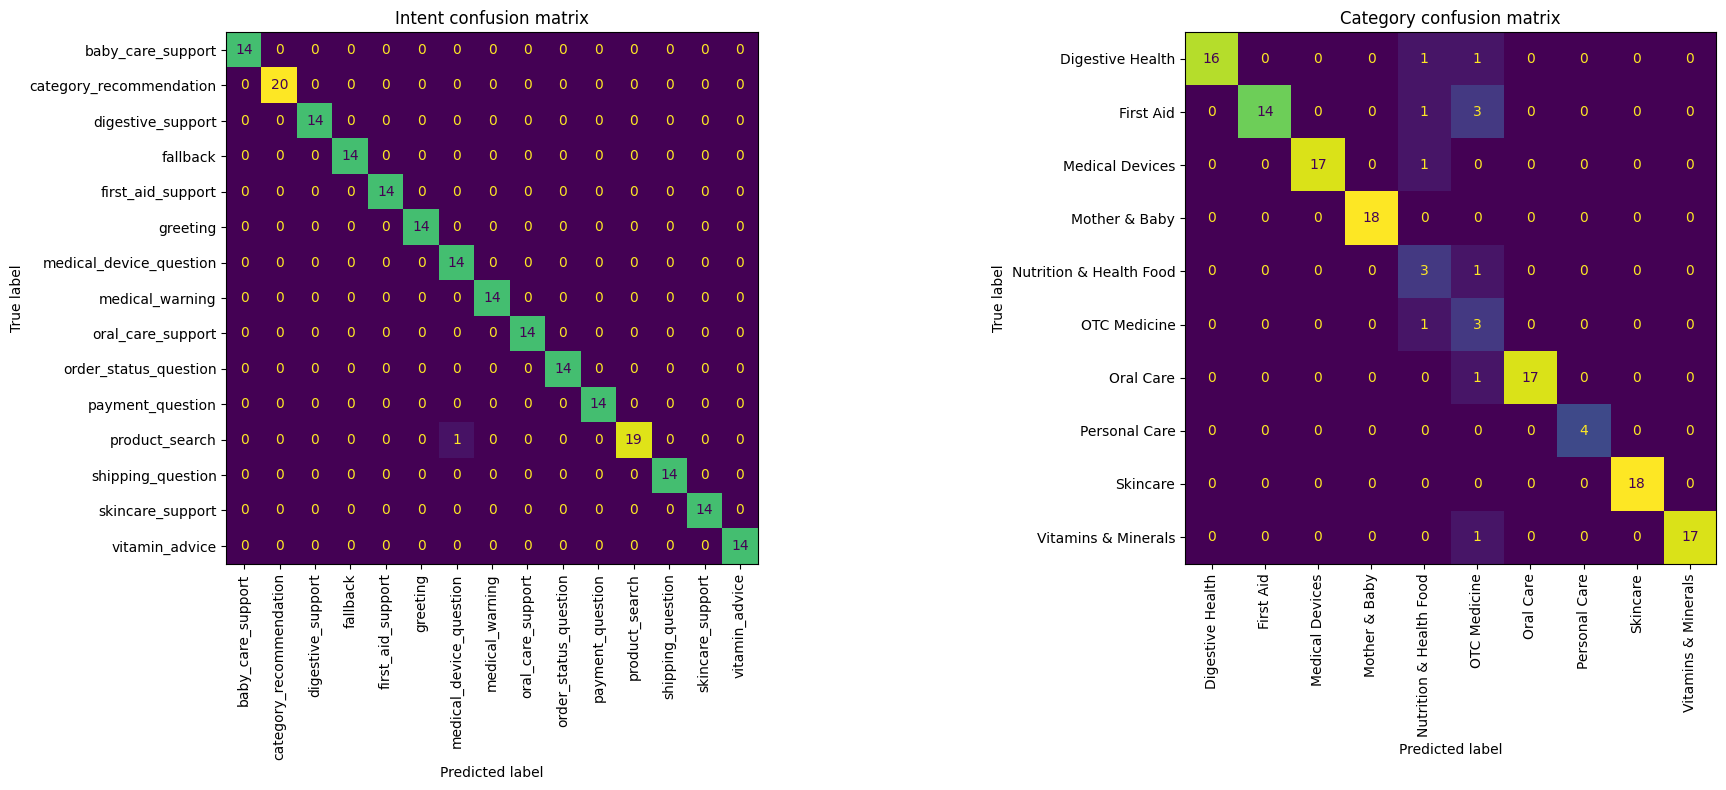

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ConfusionMatrixDisplay.from_predictions(
    intent_result['y_test'],
    intent_result['y_pred'],
    display_labels=intent_result['encoder'].classes_,
    xticks_rotation=90,
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title('Intent confusion matrix')

ConfusionMatrixDisplay.from_predictions(
    category_result['y_test'],
    category_result['y_pred'],
    display_labels=category_result['encoder'].classes_,
    xticks_rotation=90,
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title('Category confusion matrix')

plt.tight_layout()
plt.show()

## 11. Example Predictions

In [11]:
example_messages = [
    'I need something for dry skin',
    'Where is my shipment?',
    'Can you suggest vitamins for daily wellness?',
    'I have chest pain and trouble breathing',
    'Do you sell a digital thermometer?',
]

def predict_message(message):
    intent_vec = intent_result['vectorizer'].transform([message])
    category_vec = category_result['vectorizer'].transform([message])
    intent_label = intent_result['encoder'].inverse_transform(intent_result['model'].predict(intent_vec))[0]
    category_label = category_result['encoder'].inverse_transform(category_result['model'].predict(category_vec))[0]
    return {'text': message, 'predicted_intent': intent_label, 'predicted_category': category_label}

pd.DataFrame([predict_message(message) for message in example_messages])

,text,predicted_intent,predicted_category
0,I need something for dry skin,skincare_support,Skincare
1,Where is my shipment?,order_status_question,Medical Devices
2,Can you suggest vitamins for daily wellness?,vitamin_advice,Vitamins & Minerals
3,I have chest pain and trouble breathing,medical_warning,Personal Care
4,Do you sell a digital thermometer?,medical_device_question,Medical Devices


## 12. Artifact Export

In [12]:
label_encoders = {
    'intent': intent_result['encoder'],
    'category': category_result['encoder'],
}
metadata = {
    'project': 'Healthcare Pharmacy E-Commerce Microservices System',
    'model_family': 'TF-IDF + Logistic Regression baseline',
    'trained_at_utc': datetime.now(timezone.utc).isoformat(),
    'dataset_path': str(DATASET_PATH),
    'dataset_rows': int(len(df)),
    'category_training_rows': int(len(category_df)),
    'test_size': TEST_SIZE,
    'random_state': RANDOM_STATE,
    'intent_labels': metrics['intent']['labels'],
    'category_labels': metrics['category']['labels'],
    'artifact_files': [
        'intent_model.pkl',
        'intent_vectorizer.pkl',
        'category_model.pkl',
        'category_vectorizer.pkl',
        'label_encoders.pkl',
        'model_metadata.json',
        'metrics.json',
    ],
    'safety_note': 'Academic demo only. The chatbot must not diagnose disease, claim cures, replace doctor/pharmacist advice, or recommend prescription treatment.',
}

joblib.dump(intent_result['model'], ARTIFACT_DIR / 'intent_model.pkl')
joblib.dump(intent_result['vectorizer'], ARTIFACT_DIR / 'intent_vectorizer.pkl')
joblib.dump(category_result['model'], ARTIFACT_DIR / 'category_model.pkl')
joblib.dump(category_result['vectorizer'], ARTIFACT_DIR / 'category_vectorizer.pkl')
joblib.dump(label_encoders, ARTIFACT_DIR / 'label_encoders.pkl')

(ARTIFACT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')
(ARTIFACT_DIR / 'model_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')

report_lines = [
    '# Chatbot Baseline Training Metrics',
    '',
    'The chatbot models are TF-IDF + Logistic Regression baselines trained on self-seeded academic demo data.',
    '',
    '| Model | Accuracy | Precision | Recall | F1-score |',
    '|---|---:|---:|---:|---:|',
    f"| Intent classifier | {metrics['intent']['accuracy']:.4f} | {metrics['intent']['precision']:.4f} | {metrics['intent']['recall']:.4f} | {metrics['intent']['f1-score']:.4f} |",
    f"| Category classifier | {metrics['category']['accuracy']:.4f} | {metrics['category']['precision']:.4f} | {metrics['category']['recall']:.4f} | {metrics['category']['f1-score']:.4f} |",
    '',
    'Safety note: the dataset is self-seeded and is not clinically validated. The chatbot must only provide general product suggestions.',
]
(REPORT_DIR / 'chatbot_training_metrics.md').write_text('\n'.join(report_lines), encoding='utf-8')

print('Exported artifacts:')
for path in sorted(ARTIFACT_DIR.iterdir()):
    print('-', path)

Exported artifacts:
- C:\Users\nguye\Desktop\Healthcare_Pharmacy_E-Commerce\ml\artifacts\category_model.pkl
- C:\Users\nguye\Desktop\Healthcare_Pharmacy_E-Commerce\ml\artifacts\category_vectorizer.pkl
- C:\Users\nguye\Desktop\Healthcare_Pharmacy_E-Commerce\ml\artifacts\intent_model.pkl
- C:\Users\nguye\Desktop\Healthcare_Pharmacy_E-Commerce\ml\artifacts\intent_vectorizer.pkl
- C:\Users\nguye\Desktop\Healthcare_Pharmacy_E-Commerce\ml\artifacts\label_encoders.pkl
- C:\Users\nguye\Desktop\Healthcare_Pharmacy_E-Commerce\ml\artifacts\metrics.json
- C:\Users\nguye\Desktop\Healthcare_Pharmacy_E-Commerce\ml\artifacts\model_metadata.json


## 13. Django Integration Notes

After the notebook finishes on Kaggle:

1. Download the generated artifact files from `/kaggle/working/ml/artifacts/`.
2. Copy them into `services/chatbot_service/artifacts/`.
3. The chatbot service should load `intent_vectorizer.pkl` and `intent_model.pkl` to predict intent.
4. It should load `category_vectorizer.pkl` and `category_model.pkl` to predict product category recommendations.
5. It should load `label_encoders.pkl` to convert numeric predictions back to readable labels.
6. It should read `model_metadata.json` and `metrics.json` for diagnostics and report evidence.

Safety behavior remains a service responsibility. Even with model predictions, the Django chatbot service must add safe response templates, medical disclaimers when needed, and professional-help warnings for severe symptoms.